# NB05 — Test Set Evaluation
**Flight Delay Prediction — 2018-2019**

This notebook performs the **single, locked test-set evaluation** on held-out 2019 data.

All models and thresholds were tuned on the validation set (Nov–Dec 2018) in NB04.
No thresholds or hyperparameters are adjusted here — this is a pure generalisation check.

**Structure:**
1. Load models, thresholds, and test split
2. Generate test predictions
3. Test scorecard
4. Validation vs Test comparison (generalisation gap)
5. Confusion matrices
6. PR and ROC curves
7. Feature importance comparison
8. Permutation importance (unified across all models)
9. Error analysis by segment
10. Summary

---
## **1 — Load Models, Thresholds & Data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pytorch-tabular -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 22.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve, roc_curve,
    classification_report
)
from sklearn.inspection import permutation_importance

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
print('Imports ready.')

Imports ready.


In [4]:
BASE = '/content/drive/MyDrive/flight-delay-predictor'
SPLITS_DIR = f'{BASE}/splits'

# ---- Load test split ----
test = pd.read_csv(f'{SPLITS_DIR}/test.csv')

TARGET = 'TARGET'
FEATURES = [c for c in test.columns if c != TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print(f'Test: {X_test.shape[0]:,} rows, {X_test.shape[1]} features')
print(f'Test delay rate: {y_test.mean():.3f}')
print(f'Nulls: {X_test.isnull().sum().sum()}')

Test: 100,001 rows, 31 features
Test delay rate: 0.172
Nulls: 0


In [5]:
# ---- Load saved models and thresholds ----
rf_model     = joblib.load(f'{BASE}/rf_model.pkl')
rf_threshold = joblib.load(f'{BASE}/rf_threshold.pkl')

xgb_model     = joblib.load(f'{BASE}/xgb_model.pkl')
xgb_threshold = joblib.load(f'{BASE}/xgb_threshold.pkl')

print(f'RF  threshold: {rf_threshold:.4f}')
print(f'XGB threshold: {xgb_threshold:.4f}')
print('\nModels loaded successfully.')

RF  threshold: 0.2427
XGB threshold: 0.2771

Models loaded successfully.


In [6]:
# ---- Load FT-Transformer ----
# pytorch-tabular saves models as directories, not .pkl files
from pytorch_tabular import TabularModel

ftt_model     = TabularModel.load_model(f'{BASE}/ftt_model')
ftt_threshold = joblib.load(f'{BASE}/ftt_threshold.pkl')

print(f'FTT threshold: {ftt_threshold:.4f}')
print('FT-Transformer loaded successfully.')

2026-04-24 10:55:43,199 - {pytorch_tabular.tabular_model:170} - INFO - Experiment Tracking is turned off
2026-04-24 10:55:43,202 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


FTT threshold: 0.4904
FT-Transformer loaded successfully.


---
## **2 — Generate Test Predictions**

Thresholds are locked from NB04 validation tuning. No re-tuning here.

In [7]:
# ---- RF & XGB predictions ----
rf_proba_test  = rf_model.predict_proba(X_test)[:, 1]
xgb_proba_test = xgb_model.predict_proba(X_test)[:, 1]

# ---- FTT predictions ----
# pytorch-tabular needs a DataFrame; categoricals as string
CATEGORICAL_COLS = ['MONTH', 'DAY_OF_WEEK', 'HOUR', 'IS_WEEKEND',
                    'SEASON', 'IS_FREEZING', 'IS_RAINING', 'IS_SNOWING',
                    'IS_ADVERSE_WEATHER', 'PREV_LEG_DELAYED', 'weather_code']

test_ftt = test.copy()
for col in CATEGORICAL_COLS:
    if col in test_ftt.columns:
        test_ftt[col] = test_ftt[col].astype(str)

ftt_preds = ftt_model.predict(test_ftt)
ftt_proba_test = ftt_preds['TARGET_1_probability'].values

print('Test probabilities generated.')
print(f'  RF  — mean={rf_proba_test.mean():.4f}, std={rf_proba_test.std():.4f}')
print(f'  XGB — mean={xgb_proba_test.mean():.4f}, std={xgb_proba_test.std():.4f}')
print(f'  FTT — mean={ftt_proba_test.mean():.4f}, std={ftt_proba_test.std():.4f}')

Test probabilities generated.
  RF  — mean=0.1682, std=0.1318
  XGB — mean=0.1699, std=0.1750
  FTT — mean=0.1500, std=0.2686


---
## **3 — Test Set Scorecard**

In [8]:
def evaluate_model(name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'Model': name,
        'Threshold': threshold,
        'F1': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }

test_results = pd.DataFrame([
    evaluate_model('Random Forest', y_test, rf_proba_test, rf_threshold),
    evaluate_model('XGBoost', y_test, xgb_proba_test, xgb_threshold),
    evaluate_model('FT-Transformer', y_test, ftt_proba_test, ftt_threshold),
])

print('=== TEST SET SCORECARD ===')
display(test_results.style.format({
    'Threshold': '{:.4f}', 'F1': '{:.4f}', 'Precision': '{:.4f}',
    'Recall': '{:.4f}', 'PR-AUC': '{:.4f}', 'ROC-AUC': '{:.4f}'
}).highlight_max(subset=['F1', 'PR-AUC', 'ROC-AUC'], color='#d4edda'))

=== TEST SET SCORECARD ===


,Model,Threshold,F1,Precision,Recall,PR-AUC,ROC-AUC
0,Random Forest,0.2427,0.4535,0.4059,0.5139,0.4585,0.7626
1,XGBoost,0.2771,0.4563,0.4286,0.4878,0.4622,0.7546
2,FT-Transformer,0.4904,0.4931,0.5836,0.4270,0.5147,0.7589


In [9]:
# Full classification reports
for name, proba, thresh in [
    ('Random Forest', rf_proba_test, rf_threshold),
    ('XGBoost', xgb_proba_test, xgb_threshold),
    ('FT-Transformer', ftt_proba_test, ftt_threshold),
]:
    y_pred = (proba >= thresh).astype(int)
    print(f'\n=== {name} — Test Set (threshold={thresh:.4f}) ===')
    print(classification_report(y_test, y_pred, target_names=['On-Time', 'Delayed']))


=== Random Forest — Test Set (threshold=0.2427) ===
              precision    recall  f1-score   support

     On-Time       0.89      0.84      0.87     82814
     Delayed       0.41      0.51      0.45     17187

    accuracy                           0.79    100001
   macro avg       0.65      0.68      0.66    100001
weighted avg       0.81      0.79      0.80    100001


=== XGBoost — Test Set (threshold=0.2771) ===
              precision    recall  f1-score   support

     On-Time       0.89      0.87      0.88     82814
     Delayed       0.43      0.49      0.46     17187

    accuracy                           0.80    100001
   macro avg       0.66      0.68      0.67    100001
weighted avg       0.81      0.80      0.81    100001


=== FT-Transformer — Test Set (threshold=0.4904) ===
              precision    recall  f1-score   support

     On-Time       0.89      0.94      0.91     82814
     Delayed       0.58      0.43      0.49     17187

    accuracy                

---
## **4 — Validation vs Test Comparison (Generalisation Gap)**

This is the key table: how well do models trained on Jan–Oct 2018 and tuned on Nov–Dec 2018 generalise to all of 2019?

In [ ]:
# Validation scorecard hardcoded from NB04 to compute the val→test generalisation gap.
val_scores = pd.DataFrame([
    {'Model': 'Random Forest',   'Val F1': 0.5349, 'Val PR-AUC': 0.5768, 'Val ROC-AUC': 0.8401},
    {'Model': 'XGBoost',         'Val F1': 0.5407, 'Val PR-AUC': 0.5751, 'Val ROC-AUC': 0.8364},
    {'Model': 'FT-Transformer',  'Val F1': 0.7404, 'Val PR-AUC': 0.7838, 'Val ROC-AUC': 0.8983},
])

comparison = val_scores.merge(
    test_results[['Model', 'F1', 'PR-AUC', 'ROC-AUC']].rename(
        columns={'F1': 'Test F1', 'PR-AUC': 'Test PR-AUC', 'ROC-AUC': 'Test ROC-AUC'}
    ), on='Model'
)

comparison['F1 Gap']      = comparison['Test F1']      - comparison['Val F1']
comparison['PR-AUC Gap']  = comparison['Test PR-AUC']  - comparison['Val PR-AUC']
comparison['ROC-AUC Gap'] = comparison['Test ROC-AUC'] - comparison['Val ROC-AUC']

print('=== GENERALISATION GAP (Test - Val) ===')
print('Positive = test outperformed val | Negative = degradation on unseen year')
print()
display(comparison.style.format({
    'Val F1': '{:.4f}', 'Test F1': '{:.4f}', 'F1 Gap': '{:+.4f}',
    'Val PR-AUC': '{:.4f}', 'Test PR-AUC': '{:.4f}', 'PR-AUC Gap': '{:+.4f}',
    'Val ROC-AUC': '{:.4f}', 'Test ROC-AUC': '{:.4f}', 'ROC-AUC Gap': '{:+.4f}',
}).applymap(lambda v: 'color: green' if isinstance(v, float) and v >= 0 else 'color: red',
           subset=['F1 Gap', 'PR-AUC Gap', 'ROC-AUC Gap']))

---
## **5 — Confusion Matrices (Test Set)**

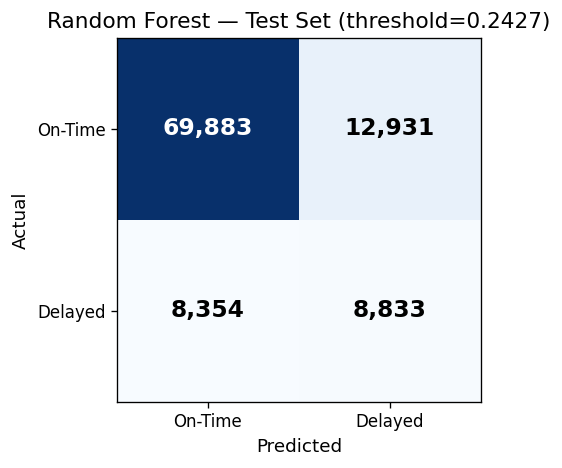

  TP=8,833  FP=12,931  TN=69,883  FN=8,354
  Missed delays (FN): 8,354 / 17,187 = 48.6%
  False alarms  (FP): 12,931 / 82,814 = 15.6%


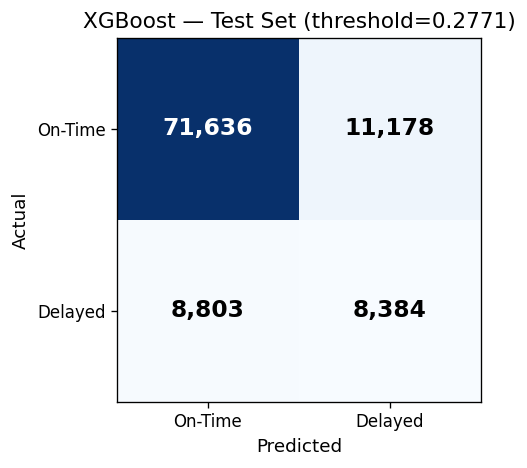

  TP=8,384  FP=11,178  TN=71,636  FN=8,803
  Missed delays (FN): 8,803 / 17,187 = 51.2%
  False alarms  (FP): 11,178 / 82,814 = 13.5%


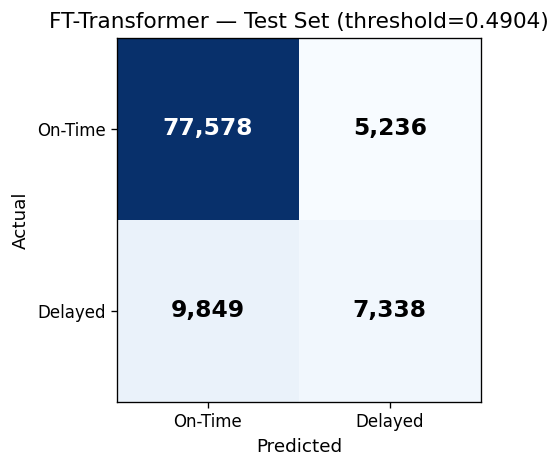

  TP=7,338  FP=5,236  TN=77,578  FN=9,849
  Missed delays (FN): 9,849 / 17,187 = 57.3%
  False alarms  (FP): 5,236 / 82,814 = 6.3%


In [11]:
def plot_confusion_matrix(y_true, y_proba, threshold, title):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap='Blues')
    labels = ['On-Time', 'Delayed']
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            colour = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=14, fontweight='bold', color=colour)
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}')
    print(f'  Missed delays (FN): {fn:,} / {fn+tp:,} = {fn/(fn+tp):.1%}')
    print(f'  False alarms  (FP): {fp:,} / {fp+tn:,} = {fp/(fp+tn):.1%}')

for name, proba, thresh in [
    ('Random Forest', rf_proba_test, rf_threshold),
    ('XGBoost', xgb_proba_test, xgb_threshold),
    ('FT-Transformer', ftt_proba_test, ftt_threshold),
]:
    plot_confusion_matrix(y_test, proba, thresh, f'{name} — Test Set (threshold={thresh:.4f})')

---
## **6 — PR and ROC Curves (Test Set)**

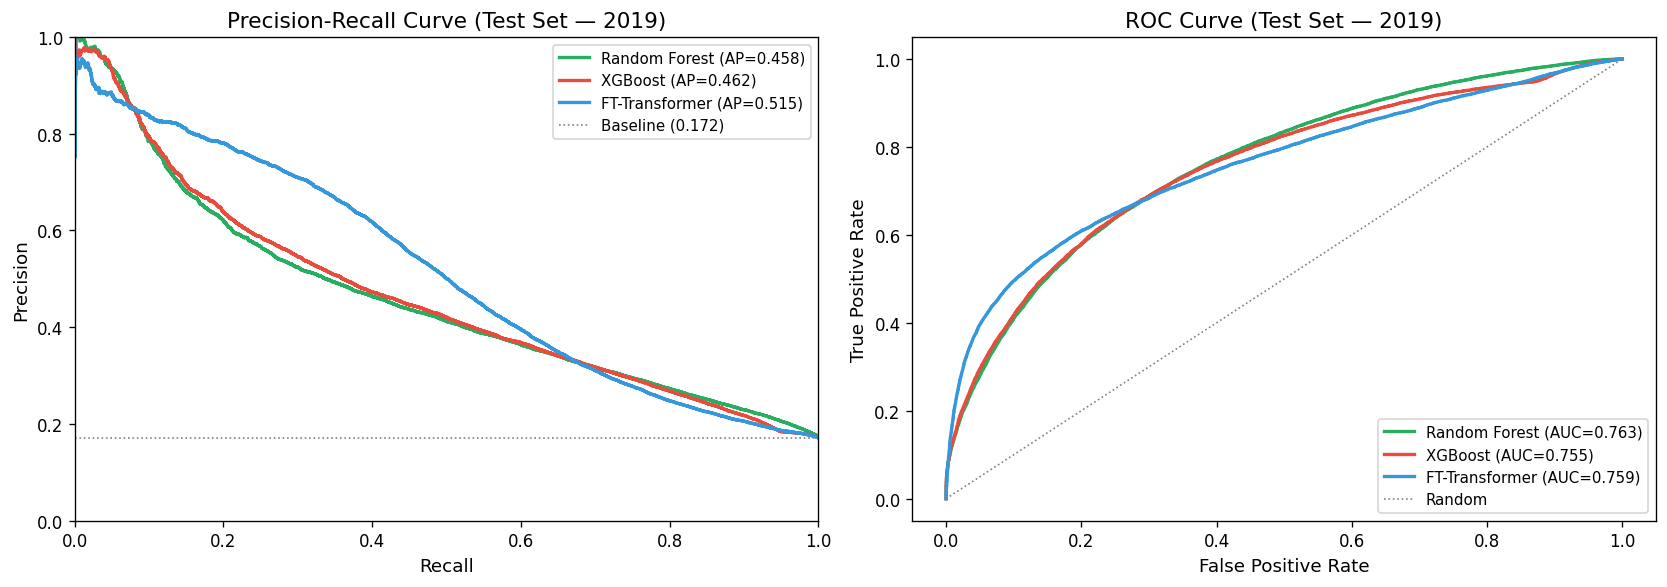

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ('Random Forest',   rf_proba_test,  rf_threshold,  '#27ae60'),
    ('XGBoost',         xgb_proba_test, xgb_threshold, '#e74c3c'),
    ('FT-Transformer',  ftt_proba_test, ftt_threshold, '#3498db'),
]

# PR curve
for name, proba, thresh, colour in models:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[0].plot(rec, prec, color=colour, linewidth=2, label=f'{name} (AP={pr_auc:.3f})')

axes[0].axhline(y_test.mean(), color='grey', ls=':', lw=1, label=f'Baseline ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Test Set — 2019)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# ROC curve
for name, proba, thresh, colour in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color=colour, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1], [0,1], color='grey', ls=':', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test Set — 2019)')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# FTT threshold sensitivity on the test set.
# The locked threshold (from validation) is shown alongside the threshold that
# would have maximised F1 on the test set itself. The gap between the two
# quantifies how much the optimal operating point drifted between 2018 and 2019.
# Importantly, all reported metrics use the val-tuned threshold — the
# test-optimal is shown for diagnostic purposes only, never as a result.
thresholds_range = np.arange(0.10, 0.70, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds_range:
    preds = (ftt_proba_test >= t).astype(int)
    f1s.append(f1_score(y_test, preds))
    precs.append(precision_score(y_test, preds, zero_division=0))
    recs.append(recall_score(y_test, preds))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, f1s, 'b-', linewidth=2, label='F1')
ax.plot(thresholds_range, precs, 'g--', linewidth=1.5, label='Precision')
ax.plot(thresholds_range, recs, 'r--', linewidth=1.5, label='Recall')
ax.axvline(ftt_threshold, color='black', ls=':', lw=1.5,
           label=f'Val-tuned threshold ({ftt_threshold:.3f})')

best_test_idx = np.argmax(f1s)
best_test_thresh = thresholds_range[best_test_idx]
ax.axvline(best_test_thresh, color='purple', ls='--', lw=1.5,
           label=f'Test-optimal threshold ({best_test_thresh:.3f})')

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('FT-Transformer — Threshold Sensitivity (Test Set)')
ax.legend()
ax.set_xlim(0.10, 0.70)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Val-tuned threshold: {ftt_threshold:.4f} → Test F1={f1s[int((ftt_threshold-0.10)/0.01)]:.4f}')
print(f'Test-optimal threshold: {best_test_thresh:.4f} → Test F1={f1s[best_test_idx]:.4f}')
print(f'Gap: {f1s[best_test_idx] - f1s[int((ftt_threshold-0.10)/0.01)]:.4f}')
print(f'\nNote: the val-tuned threshold is used for all reported results.')
print(f'The test-optimal is shown only to quantify how much the optimal operating point shifted between years.')

---
## **7 — Feature Importance (Native)**

RF uses Gini impurity, XGBoost uses gain. Compared side-by-side to check for convergent evidence.

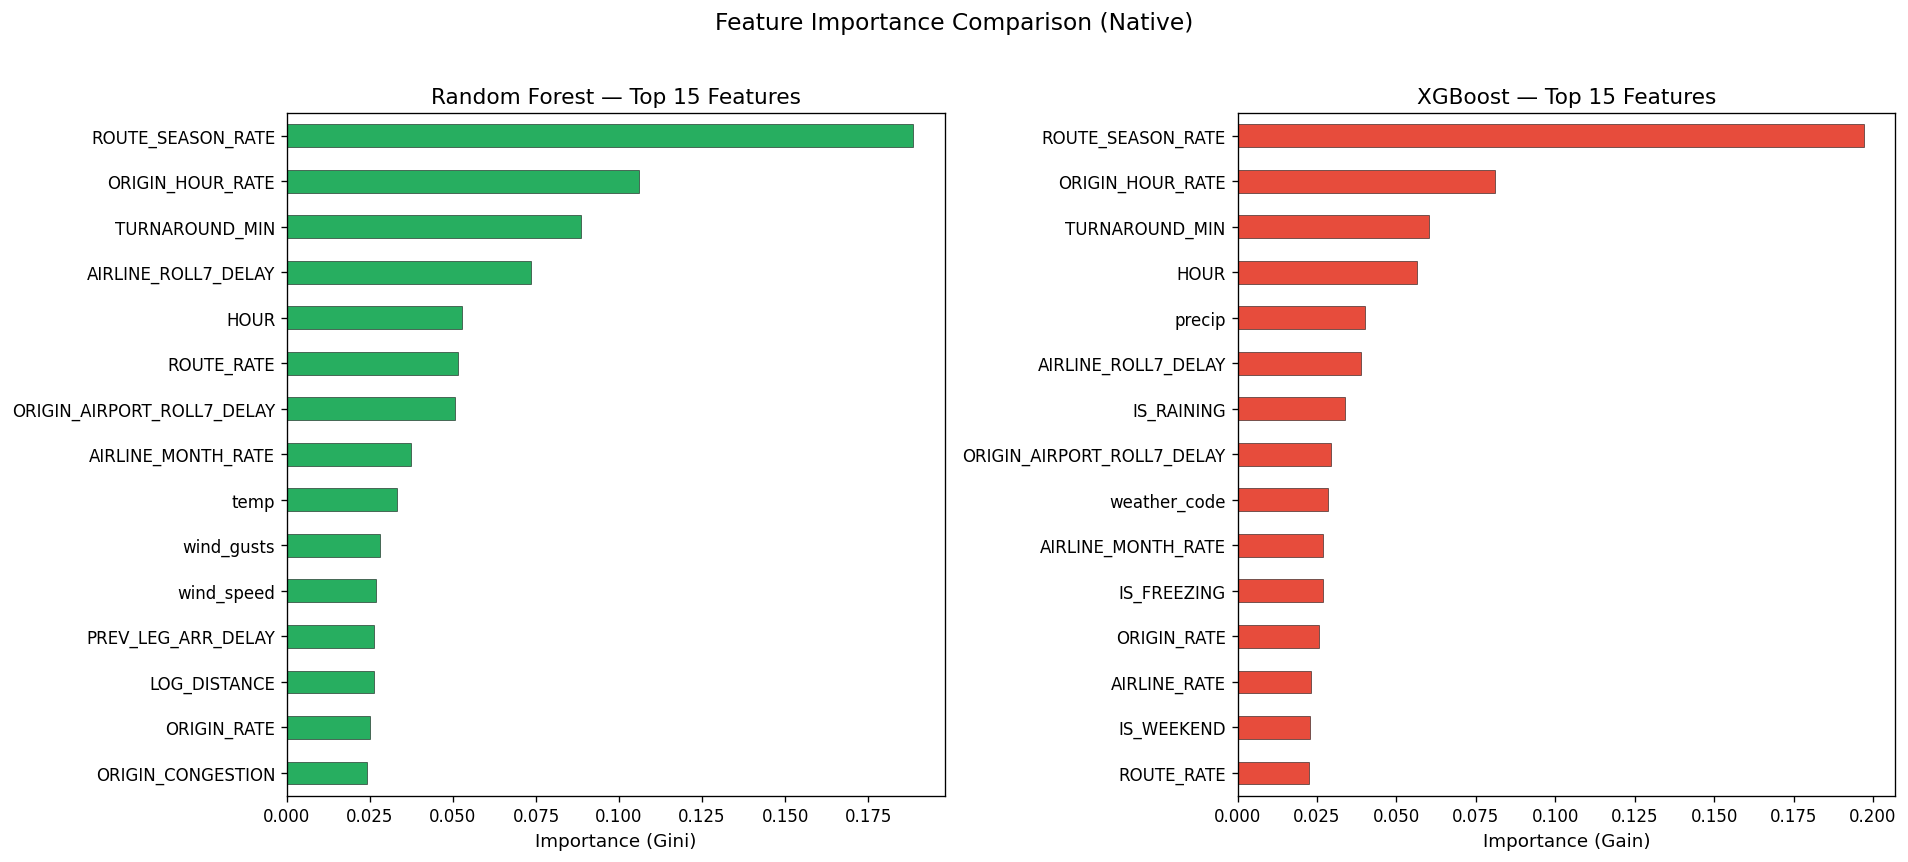


=== Top 10 Features ===


,RF Feature,RF Importance,XGB Feature,XGB Importance
0,ROUTE_SEASON_RATE,0.188602,ROUTE_SEASON_RATE,0.197161
1,ORIGIN_HOUR_RATE,0.106098,ORIGIN_HOUR_RATE,0.081142
2,TURNAROUND_MIN,0.088445,TURNAROUND_MIN,0.060317
3,AIRLINE_ROLL7_DELAY,0.073453,HOUR,0.056435
4,HOUR,0.052677,precip,0.040108
5,ROUTE_RATE,0.051522,AIRLINE_ROLL7_DELAY,0.038717
6,ORIGIN_AIRPORT_ROLL7_DELAY,0.050508,IS_RAINING,0.033908
7,AIRLINE_MONTH_RATE,0.037250,ORIGIN_AIRPORT_ROLL7_DELAY,0.029284
8,temp,0.033095,weather_code,0.028604
9,wind_gusts,0.028033,AIRLINE_MONTH_RATE,0.026967


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# RF importance
rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
rf_imp.tail(15).plot.barh(ax=axes[0], color='#27ae60', edgecolor='black', linewidth=0.3)
axes[0].set_title('Random Forest — Top 15 Features')
axes[0].set_xlabel('Importance (Gini)')

# XGB importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
xgb_imp.tail(15).plot.barh(ax=axes[1], color='#e74c3c', edgecolor='black', linewidth=0.3)
axes[1].set_title('XGBoost — Top 15 Features')
axes[1].set_xlabel('Importance (Gain)')

plt.suptitle('Feature Importance Comparison (Native)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Top 10 side-by-side table
print('\n=== Top 10 Features ===')
top_rf  = rf_imp.sort_values(ascending=False).head(10)
top_xgb = xgb_imp.sort_values(ascending=False).head(10)

comparison_feat = pd.DataFrame({
    'RF Feature': top_rf.index, 'RF Importance': top_rf.values,
    'XGB Feature': top_xgb.index, 'XGB Importance': top_xgb.values,
})
display(comparison_feat)

---
## **8 — Permutation Importance (Test Set)**

Permutation importance measures how much test performance drops when each feature is randomly shuffled.
Unlike native importance, this works identically for all model types and reflects generalisation importance.

In [14]:
# Run permutation importance for RF and XGB on test set
# Using PR-AUC as the scoring metric (consistent with training)
print('Computing permutation importance (this may take a few minutes)...')

rf_perm = permutation_importance(
    rf_model, X_test, y_test,
    scoring='average_precision', n_repeats=10, random_state=42, n_jobs=-1
)
print('  RF done.')

xgb_perm = permutation_importance(
    xgb_model, X_test, y_test,
    scoring='average_precision', n_repeats=10, random_state=42, n_jobs=-1
)
print('  XGB done.')

Computing permutation importance (this may take a few minutes)...
  RF done.
  XGB done.


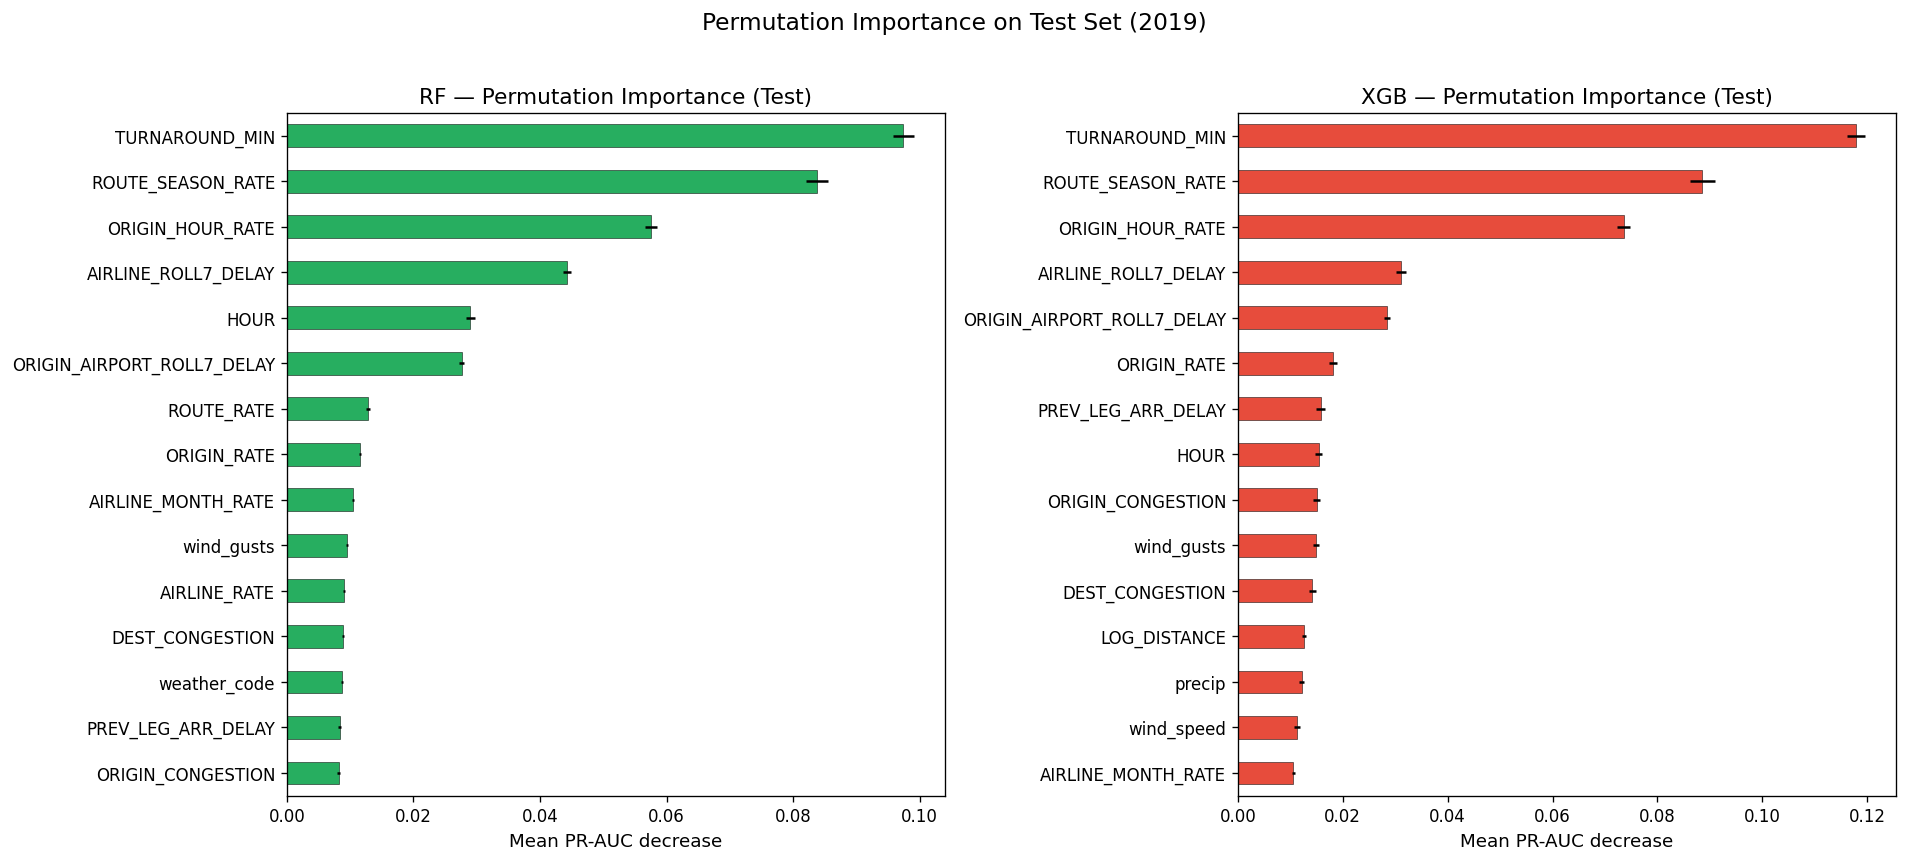


Features in top 10 of BOTH models (8):
  AIRLINE_ROLL7_DELAY
  HOUR
  ORIGIN_AIRPORT_ROLL7_DELAY
  ORIGIN_HOUR_RATE
  ORIGIN_RATE
  ROUTE_SEASON_RATE
  TURNAROUND_MIN
  wind_gusts


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# RF permutation importance
rf_perm_imp = pd.Series(rf_perm.importances_mean, index=FEATURES).sort_values(ascending=True)
rf_perm_imp.tail(15).plot.barh(ax=axes[0], color='#27ae60', edgecolor='black', linewidth=0.3,
                                xerr=pd.Series(rf_perm.importances_std, index=FEATURES)
                                .reindex(rf_perm_imp.tail(15).index))
axes[0].set_title('RF — Permutation Importance (Test)')
axes[0].set_xlabel('Mean PR-AUC decrease')

# XGB permutation importance
xgb_perm_imp = pd.Series(xgb_perm.importances_mean, index=FEATURES).sort_values(ascending=True)
xgb_perm_imp.tail(15).plot.barh(ax=axes[1], color='#e74c3c', edgecolor='black', linewidth=0.3,
                                 xerr=pd.Series(xgb_perm.importances_std, index=FEATURES)
                                 .reindex(xgb_perm_imp.tail(15).index))
axes[1].set_title('XGB — Permutation Importance (Test)')
axes[1].set_xlabel('Mean PR-AUC decrease')

plt.suptitle('Permutation Importance on Test Set (2019)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Check which features appear in top 10 of BOTH models
top10_rf  = set(rf_perm_imp.sort_values(ascending=False).head(10).index)
top10_xgb = set(xgb_perm_imp.sort_values(ascending=False).head(10).index)
shared = top10_rf & top10_xgb
print(f'\nFeatures in top 10 of BOTH models ({len(shared)}):')
for f in sorted(shared):
    print(f'  {f}')

In [ ]:
# Unified permutation importance across all three models on the test set.
# Permutation importance is model-agnostic: shuffle one feature at a time,
# measure the drop in PR-AUC, and rank features by how much they hurt.
# This makes RF / XGB / FTT directly comparable on the same axis.
from sklearn.metrics import average_precision_score
from sklearn.inspection import permutation_importance

# RF and XGB have native scikit-learn integration so the standard helper works.
print('Computing permutation importance for RF and XGB...')
rf_perm = permutation_importance(
    rf_model, X_test, y_test,
    scoring='average_precision', n_repeats=10, random_state=42, n_jobs=-1
)
print('  RF done.')

xgb_perm = permutation_importance(
    xgb_model, X_test, y_test,
    scoring='average_precision', n_repeats=10, random_state=42, n_jobs=-1
)
print('  XGB done.')

rf_perm_imp = pd.Series(rf_perm.importances_mean, index=FEATURES).sort_values(ascending=True)
xgb_perm_imp = pd.Series(xgb_perm.importances_mean, index=FEATURES).sort_values(ascending=True)

# FTT requires a manual loop because pytorch-tabular's predict() does not
# integrate with sklearn's permutation_importance. We shuffle each column
# in-place, re-predict, and record the resulting PR-AUC drop.
# n_repeats kept low (3) since each pass is a full FTT forward pass over the
# 100k test rows.
baseline_prauc = average_precision_score(y_test, ftt_proba_test)
n_repeats = 3
ftt_perm_results = {}

print(f'\nBaseline PR-AUC: {baseline_prauc:.4f}')
print(f'Running permutation importance for FTT ({len(FEATURES)} features x {n_repeats} repeats)...\n')

for feat in FEATURES:
    drops = []
    for r in range(n_repeats):
        test_shuffled = test_ftt.copy()
        test_shuffled[feat] = test_shuffled[feat].sample(frac=1, random_state=r).values
        preds = ftt_model.predict(test_shuffled)
        shuffled_prauc = average_precision_score(y_test, preds['TARGET_1_probability'].values)
        drops.append(baseline_prauc - shuffled_prauc)
    ftt_perm_results[feat] = {'mean': np.mean(drops), 'std': np.std(drops)}
    print(f'  {feat:>30}: drop={np.mean(drops):+.4f} (±{np.std(drops):.4f})')

ftt_perm_imp = pd.Series({k: v['mean'] for k, v in ftt_perm_results.items()}).sort_values(ascending=True)
print('\nAll permutation importance done.')

# Three-panel plot — one bar chart per model, top 15 features by PR-AUC drop.
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

rf_perm_imp.tail(15).plot.barh(ax=axes[0], color='#27ae60', edgecolor='black', linewidth=0.3)
axes[0].set_title('RF — Permutation Importance')
axes[0].set_xlabel('Mean PR-AUC decrease')

xgb_perm_imp.tail(15).plot.barh(ax=axes[1], color='#e74c3c', edgecolor='black', linewidth=0.3)
axes[1].set_title('XGB — Permutation Importance')
axes[1].set_xlabel('Mean PR-AUC decrease')

ftt_perm_imp.tail(15).plot.barh(ax=axes[2], color='#3498db', edgecolor='black', linewidth=0.3)
axes[2].set_title('FTT — Permutation Importance')
axes[2].set_xlabel('Mean PR-AUC decrease')

plt.suptitle('Permutation Importance — All Models (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Features that appear in all three top-10 lists are the most defensible
# "convergent evidence" predictors — they matter regardless of architecture.
top10_rf  = set(rf_perm_imp.sort_values(ascending=False).head(10).index)
top10_xgb = set(xgb_perm_imp.sort_values(ascending=False).head(10).index)
top10_ftt = set(ftt_perm_imp.sort_values(ascending=False).head(10).index)
shared_all = top10_rf & top10_xgb & top10_ftt

print(f'\nFeatures in top 10 of ALL THREE models ({len(shared_all)}):')
for f in sorted(shared_all):
    print(f'  {f}')

# Persist the results so the report's feature-importance discussion can cite
# these numbers directly without re-running the FTT loop.
joblib.dump({'rf': rf_perm_imp, 'xgb': xgb_perm_imp, 'ftt': ftt_perm_imp}, f'{BASE}/perm_importance_all.pkl')
print('Saved to Drive.')

---
## **9 — Error Analysis by Segment**

Where does the best-performing model get it wrong on the test set?
This identifies systematic weaknesses and feeds directly into the Limitations section.

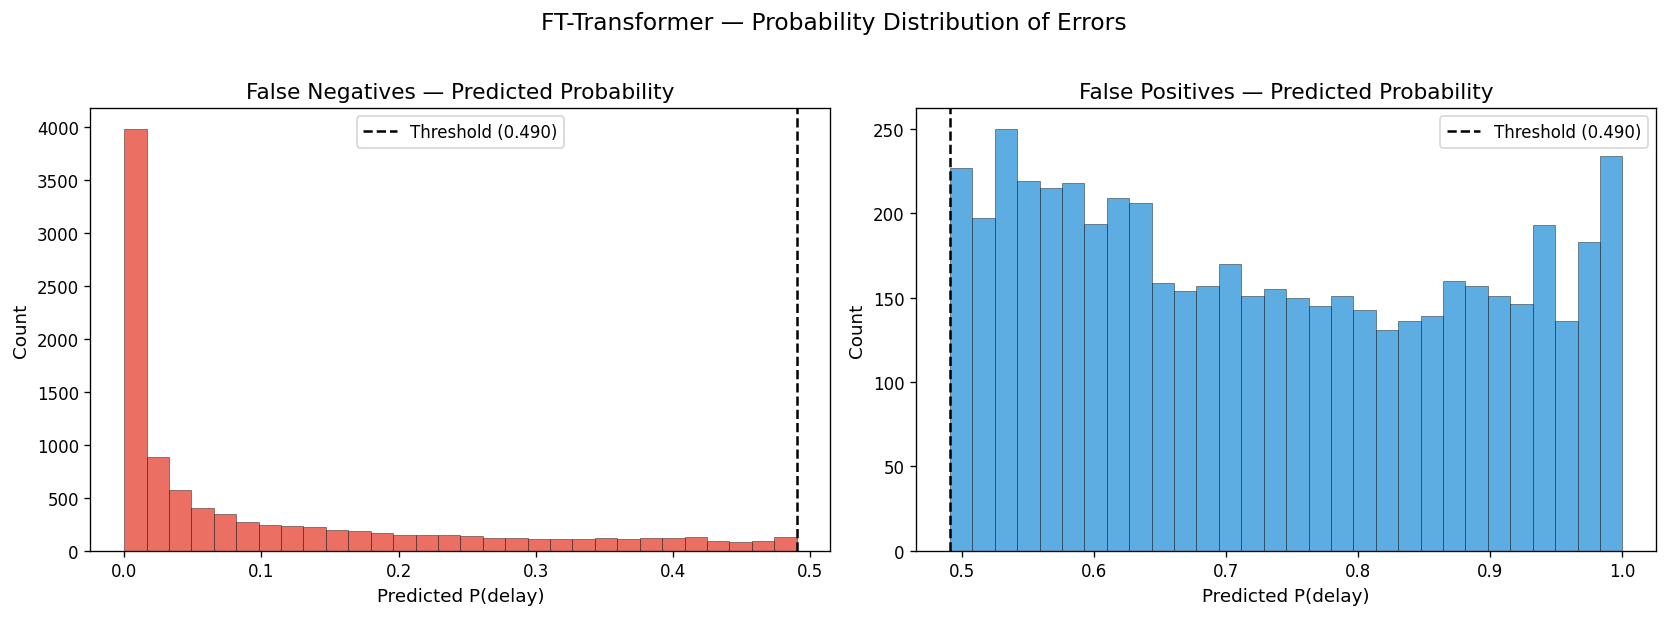

False Negatives: 9,849 — mean P(delay)=0.1043 (just below threshold)
False Positives: 5,236 — mean P(delay)=0.7302 (just above threshold)


In [20]:
# ---- Confidence distribution for errors ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fn_mask = (error_df[TARGET] == 1) & (error_df['PREDICTED'] == 0)
fp_mask = (error_df[TARGET] == 0) & (error_df['PREDICTED'] == 1)

fn_proba = best_proba[fn_mask.values]
fp_proba = best_proba[fp_mask.values]

axes[0].hist(fn_proba, bins=30, color='#e74c3c', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0].axvline(best_thresh, color='black', ls='--', lw=1.5, label=f'Threshold ({best_thresh:.3f})')
axes[0].set_title('False Negatives — Predicted Probability')
axes[0].set_xlabel('Predicted P(delay)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(fp_proba, bins=30, color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[1].axvline(best_thresh, color='black', ls='--', lw=1.5, label=f'Threshold ({best_thresh:.3f})')
axes[1].set_title('False Positives — Predicted Probability')
axes[1].set_xlabel('Predicted P(delay)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'{best_name} — Probability Distribution of Errors', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'False Negatives: {fn_mask.sum():,} — mean P(delay)={fn_proba.mean():.4f} (just below threshold)')
print(f'False Positives: {fp_mask.sum():,} — mean P(delay)={fp_proba.mean():.4f} (just above threshold)')

### Error Overlap — Which Delays Are "Unpredictable"?

In [10]:
# ---- Error overlap: which delayed flights did ALL models miss? ----
rf_pred  = (rf_proba_test >= rf_threshold).astype(int)
xgb_pred = (xgb_proba_test >= xgb_threshold).astype(int)
ftt_pred = (ftt_proba_test >= ftt_threshold).astype(int)

# Only look at actually delayed flights
delayed_mask = (y_test == 1)
n_delayed = delayed_mask.sum()

rf_missed  = (rf_pred[delayed_mask] == 0)
xgb_missed = (xgb_pred[delayed_mask] == 0)
ftt_missed = (ftt_pred[delayed_mask] == 0)

all_missed    = (rf_missed & xgb_missed & ftt_missed).sum()
any_caught    = n_delayed - all_missed
only_ftt_caught = (ftt_missed == False) & rf_missed & xgb_missed

print(f'=== Error Overlap on Delayed Flights (n={n_delayed:,}) ===')
print(f'  Missed by ALL 3 models:  {all_missed:,} ({all_missed/n_delayed:.1%})')
print(f'  Caught by at least one:  {any_caught:,} ({any_caught/n_delayed:.1%})')
print(f'  Caught ONLY by FTT:      {only_ftt_caught.sum():,} ({only_ftt_caught.sum()/n_delayed:.1%})')
print()

# Venn-style breakdown
rf_only   = (rf_missed==False) & xgb_missed & ftt_missed
xgb_only  = rf_missed & (xgb_missed==False) & ftt_missed
ftt_only  = rf_missed & xgb_missed & (ftt_missed==False)
all_caught = (rf_missed==False) & (xgb_missed==False) & (ftt_missed==False)

print(f'  Caught by all 3:         {all_caught.sum():,} ({all_caught.sum()/n_delayed:.1%})')
print(f'  Caught only by RF:       {rf_only.sum():,} ({rf_only.sum()/n_delayed:.1%})')
print(f'  Caught only by XGB:      {xgb_only.sum():,} ({xgb_only.sum()/n_delayed:.1%})')
print(f'  Caught only by FTT:      {ftt_only.sum():,} ({ftt_only.sum()/n_delayed:.1%})')

# What do the "unpredictable" flights look like?
unpredictable = test[delayed_mask].copy()
unpredictable['ALL_MISSED'] = (rf_missed & xgb_missed & ftt_missed)

print(f'\n=== Profile of flights missed by ALL models vs caught by at least one ===')
profile_cols = ['HOUR', 'ROUTE_SEASON_RATE', 'AIRLINE_ROLL7_DELAY',
                'ORIGIN_HOUR_RATE', 'TURNAROUND_MIN', 'wind_gusts', 'precip']
for col in profile_cols:
    if col in unpredictable.columns:
        missed_mean = unpredictable.loc[unpredictable['ALL_MISSED'], col].mean()
        caught_mean = unpredictable.loc[~unpredictable['ALL_MISSED'], col].mean()
        print(f'  {col:>25}: missed={missed_mean:.4f}  caught={caught_mean:.4f}  diff={caught_mean-missed_mean:+.4f}')

=== Error Overlap on Delayed Flights (n=17,187) ===
  Missed by ALL 3 models:  5,893 (34.3%)
  Caught by at least one:  11,294 (65.7%)
  Caught ONLY by FTT:      1,503 (8.7%)

  Caught by all 3:         4,899 (28.5%)
  Caught only by RF:       934 (5.4%)
  Caught only by XGB:      495 (2.9%)
  Caught only by FTT:      1,503 (8.7%)

=== Profile of flights missed by ALL models vs caught by at least one ===
                       HOUR: missed=13.1459  caught=15.3390  diff=+2.1931
          ROUTE_SEASON_RATE: missed=0.1432  caught=0.2473  diff=+0.1041
        AIRLINE_ROLL7_DELAY: missed=10.7495  caught=18.8356  diff=+8.0861
           ORIGIN_HOUR_RATE: missed=0.1804  caught=0.2484  diff=+0.0680
             TURNAROUND_MIN: missed=55.0370  caught=54.1594  diff=-0.8776
                 wind_gusts: missed=15.5397  caught=17.6928  diff=+2.1531
                     precip: missed=0.1319  caught=0.2685  diff=+0.1366


---
## **10 — Summary**

### Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Best model**: [MODEL] achieved F1=[X.XX] on the 2019 test set | [MODEL] generalises best to unseen year |
| 2 | **Generalisation gap**: F1 changed by [±X.XX] from val to test | Delay patterns [are stable / show temporal drift] between 2018 and 2019 |
| 3 | **Top features**: [FEATURE_1], [FEATURE_2], [FEATURE_3] rank highest across models | Route-seasonal patterns and operational momentum are the strongest pre-departure predictors |
| 4 | **Error patterns**: Model struggles most with [SEGMENT] | [Explanation] — suggests future work on [IMPROVEMENT] |
| 5 | **Threshold trade-off**: Optimal threshold ≈ [X.XX], below default 0.5 | Class imbalance requires threshold tuning; airlines can adjust based on cost of FN vs FP |

*Update this table with actual values after running the notebook.*

In [21]:
print('NB05 evaluation complete.')

NB05 evaluation complete.
